In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
WAID_DIR = DATA_RAW / "waid"
COCO_DIR = DATA_RAW / "coco_cow_sheep" / "exported"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)

print("WAID:", WAID_DIR)
print("COCO:", COCO_DIR)


WAID: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/raw/waid
COCO: /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/data/raw/coco_cow_sheep/exported


In [2]:
def class_name(names, cls_id):
    if isinstance(names, dict):
        return names.get(cls_id, f"cls_{cls_id}")
    if isinstance(names, list):
        if 0 <= cls_id < len(names):
            return names[cls_id]
    return f"cls_{cls_id}"

with open(WAID_DIR / "data.yaml") as f:
    waid_meta = yaml.safe_load(f)
waid_names = waid_meta["names"]

waid_rows = []
for split in ("train", "valid", "test"):
    imgs_dir = WAID_DIR / split / "images"
    lbls_dir = WAID_DIR / split / "labels"
    for img in imgs_dir.glob("*.jpg"):
        lbl = lbls_dir / (img.stem + ".txt")
        classes = []
        bboxes = []
        if lbl.exists():
            for line in lbl.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    classes.append(class_name(waid_names, cls_id))
                    bboxes.append(tuple(float(x) for x in parts[1:5]))
        waid_rows.append({
            "source": "waid",
            "split": split,
            "image_path": str(img),
            "n_boxes": len(classes),
            "classes": classes,
            "bboxes": bboxes,
        })
waid_df = pd.DataFrame(waid_rows)

with open(COCO_DIR / "dataset.yaml") as f:
    coco_meta = yaml.safe_load(f)
coco_names = coco_meta["names"]

coco_rows = []
coco_imgs_dir = COCO_DIR / "images" / "val"
coco_lbls_dir = COCO_DIR / "labels" / "val"
for img in coco_imgs_dir.glob("*"):
    if img.suffix.lower() not in (".jpg", ".jpeg", ".png"):
        continue
    lbl = coco_lbls_dir / (img.stem + ".txt")
    classes = []
    bboxes = []
    if lbl.exists():
        for line in lbl.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                name = class_name(coco_names, cls_id)
                if name == "cow":
                    name = "cattle"
                classes.append(name)
                bboxes.append(tuple(float(x) for x in parts[1:5]))
    coco_rows.append({
        "source": "coco",
        "split": "all",
        "image_path": str(img),
        "n_boxes": len(classes),
        "classes": classes,
        "bboxes": bboxes,
    })
coco_df = pd.DataFrame(coco_rows)

print("WAID rows:", len(waid_df))
print("COCO rows:", len(coco_df))
waid_df.head()


WAID rows: 14366
COCO rows: 3393


,source,split,image_path,n_boxes,classes,bboxes
0,waid,train,/Users/m/Documents/capstone-msc-da-feb-25-coho...,3,"[zebra, zebra, zebra]","[(0.2359375, 0.61875, 0.09609375, 0.21015625),..."
1,waid,train,/Users/m/Documents/capstone-msc-da-feb-25-coho...,19,"[cattle, cattle, cattle, cattle, cattle, cattl...","[(0.6671875, 0.92734375, 0.075, 0.1421875), (0..."
2,waid,train,/Users/m/Documents/capstone-msc-da-feb-25-coho...,8,"[cattle, cattle, cattle, cattle, cattle, cattl...","[(0.80859375, 0.7328125, 0.090625, 0.103125), ..."
3,waid,train,/Users/m/Documents/capstone-msc-da-feb-25-coho...,13,"[seal, seal, seal, seal, seal, seal, seal, sea...","[(0.084375, 0.58828125, 0.071875, 0.084375), (..."
4,waid,train,/Users/m/Documents/capstone-msc-da-feb-25-coho...,29,"[cattle, cattle, cattle, cattle, cattle, cattl...","[(0.58046875, 0.403125, 0.0390625, 0.0234375),..."


WAID bbox class counts:
sheep      130810
cattle      63090
seal        23362
camelus      6623
zebra        5225
kiang        4609
Name: count, dtype: int64

COCO bbox class counts:
sheep     9509
cattle    8147
Name: count, dtype: int64


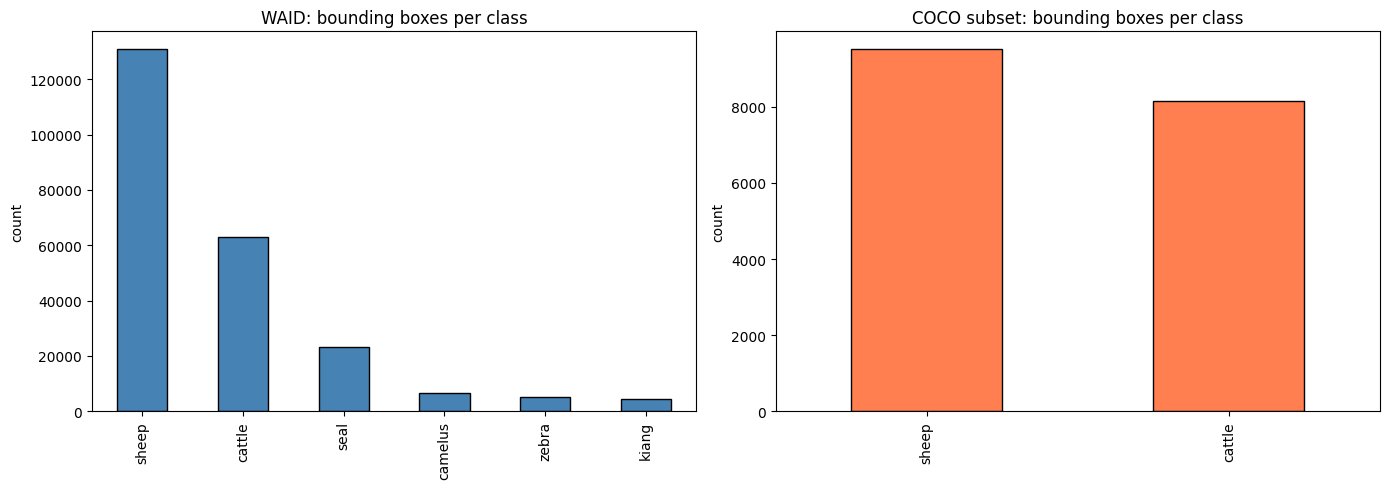

In [3]:
waid_class_counts = pd.Series([c for cs in waid_df["classes"] for c in cs]).value_counts()
coco_class_counts = pd.Series([c for cs in coco_df["classes"] for c in cs]).value_counts()

print("WAID bbox class counts:")
print(waid_class_counts)
print()
print("COCO bbox class counts:")
print(coco_class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
waid_class_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("WAID: bounding boxes per class")
axes[0].set_ylabel("count")
coco_class_counts.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("COCO subset: bounding boxes per class")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()


WAID image size describe():
        width  height  aspect
count  1000.0  1000.0  1000.0
mean    640.0   640.0     1.0
std       0.0     0.0     0.0
min     640.0   640.0     1.0
25%     640.0   640.0     1.0
50%     640.0   640.0     1.0
75%     640.0   640.0     1.0
max     640.0   640.0     1.0

COCO image size describe():
             width       height       aspect
count  1000.000000  1000.000000  1000.000000
mean    612.857000   458.845000     1.382367
std      65.781394    80.352184     0.302795
min     267.000000   165.000000     0.632812
25%     640.000000   426.000000     1.333333
50%     640.000000   439.500000     1.367521
75%     640.000000   480.000000     1.498829
max     640.000000   640.000000     3.878788


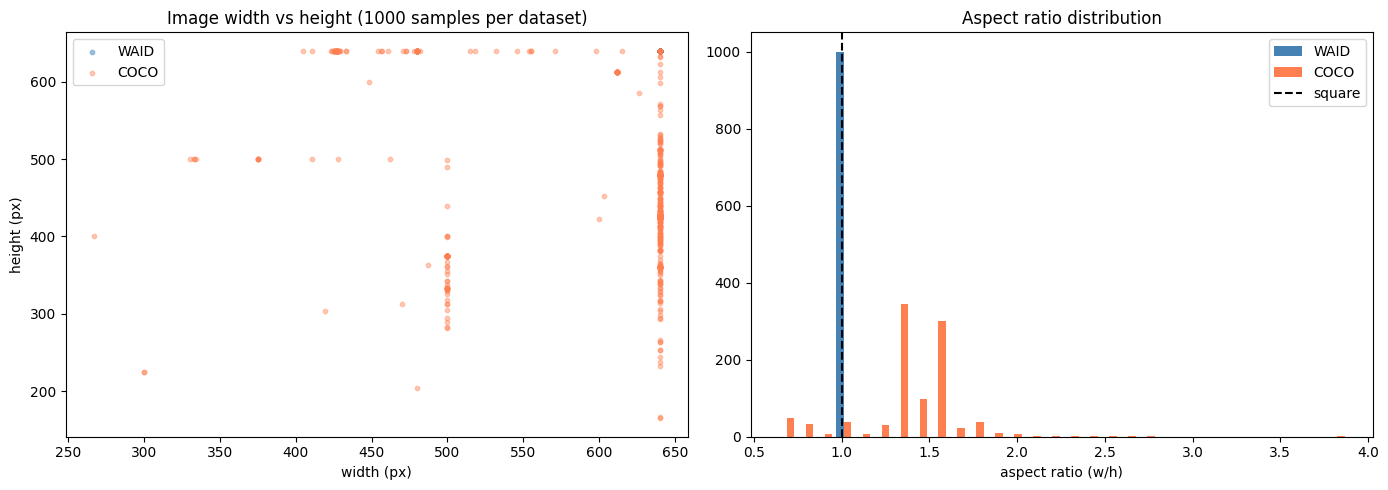

In [4]:
def sample_image_sizes(df, n=1000, seed=SEED):
    sample = df.sample(min(n, len(df)), random_state=seed)
    rows = []
    for _, r in sample.iterrows():
        try:
            with Image.open(r["image_path"]) as img:
                w, h = img.size
            rows.append({"source": r["source"], "width": w, "height": h, "aspect": w / h})
        except Exception:
            rows.append({"source": r["source"], "width": np.nan, "height": np.nan, "aspect": np.nan})
    return pd.DataFrame(rows)

sizes_waid = sample_image_sizes(waid_df, n=1000)
sizes_coco = sample_image_sizes(coco_df, n=1000)

print("WAID image size describe():")
print(sizes_waid[["width", "height", "aspect"]].describe())
print()
print("COCO image size describe():")
print(sizes_coco[["width", "height", "aspect"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(sizes_waid["width"], sizes_waid["height"], alpha=0.4, s=10, label="WAID")
axes[0].scatter(sizes_coco["width"], sizes_coco["height"], alpha=0.4, s=10, color="coral", label="COCO")
axes[0].set_xlabel("width (px)")
axes[0].set_ylabel("height (px)")
axes[0].legend()
axes[0].set_title("Image width vs height (1000 samples per dataset)")

axes[1].hist(
    [sizes_waid["aspect"].dropna(), sizes_coco["aspect"].dropna()],
    bins=30, label=["WAID", "COCO"], color=["steelblue", "coral"],
)
axes[1].axvline(1.0, color="black", linestyle="--", label="square")
axes[1].set_xlabel("aspect ratio (w/h)")
axes[1].legend()
axes[1].set_title("Aspect ratio distribution")
plt.tight_layout()
plt.show()


WAID pixel stats:
             mean         std        skew        kurt
count  400.000000  400.000000  400.000000  400.000000
mean   124.987892   35.624245   -0.301061    2.044716
std     32.995651   12.309906    1.090784    4.811993
min     43.591904   10.097001   -4.484864   -1.606161
25%    103.594849   27.204771   -0.831396   -0.146121
50%    124.284996   34.837210   -0.128001    0.964299
75%    146.331188   42.835876    0.470404    2.310185
max    244.739929   78.360474    2.379527   43.315291

COCO pixel stats:
             mean         std        skew        kurt
count  400.000000  400.000000  400.000000  400.000000
mean   113.570206   59.639206    0.277657   -0.437375
std     24.748037   13.975639    0.557274    1.715395
min     47.373314   16.284994   -4.505981   -1.812038
25%     97.075865   49.128035   -0.022775   -1.050371
50%    111.891045   59.448406    0.280100   -0.637758
75%    129.943474   69.296331    0.616036   -0.145021
max    223.531204   96.884789    1.788731   3

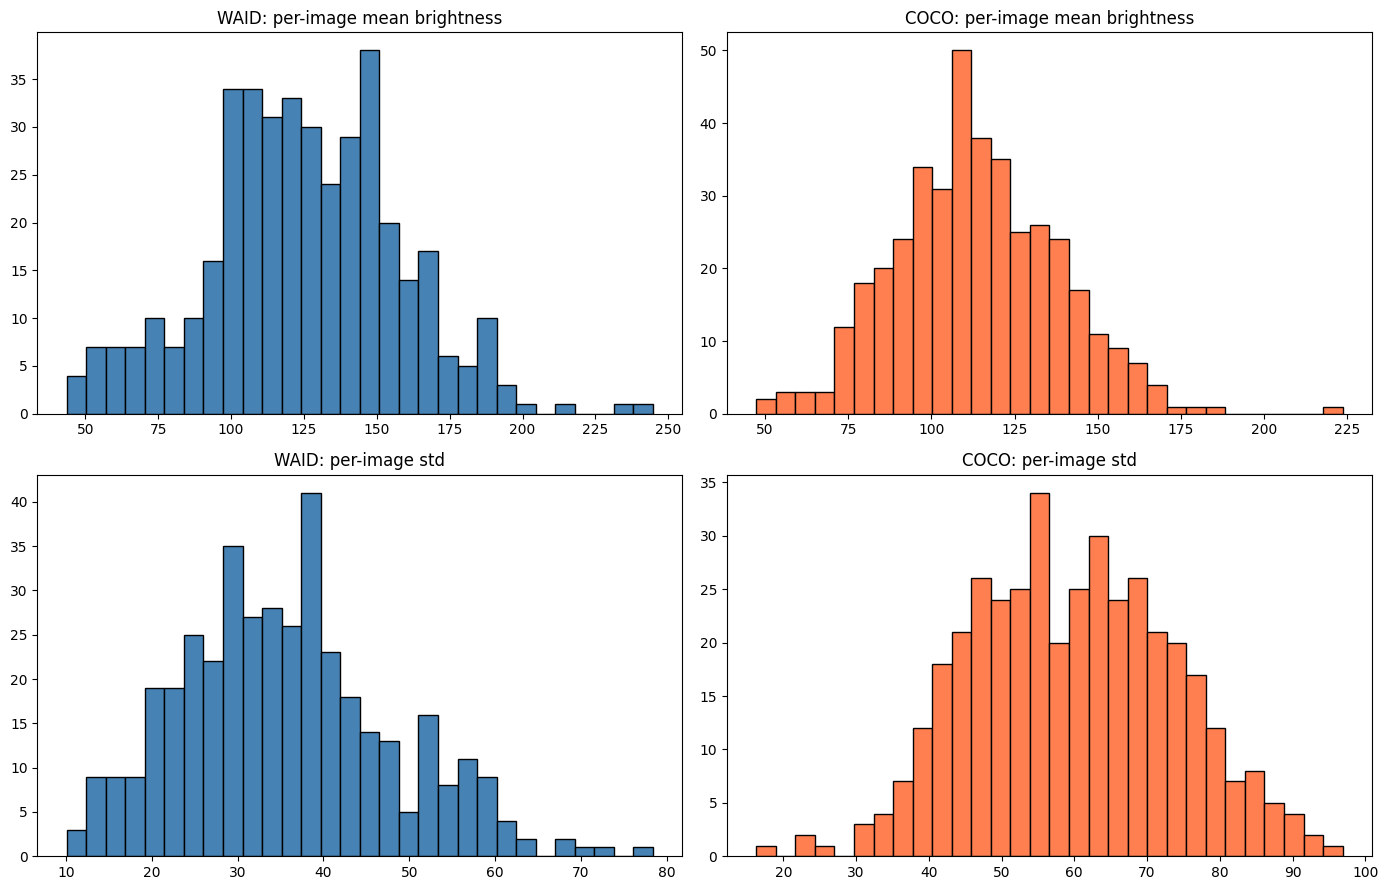

In [5]:
def pixel_stats(df, n=400, seed=SEED, target=224):
    sample = df.sample(min(n, len(df)), random_state=seed)
    rows = []
    for _, r in sample.iterrows():
        try:
            img = Image.open(r["image_path"]).convert("RGB").resize((target, target))
            arr = np.asarray(img).astype(np.float32)
            flat = arr.flatten()
            rows.append({
                "source": r["source"],
                "mean": arr.mean(),
                "std": arr.std(),
                "skew": stats.skew(flat),
                "kurt": stats.kurtosis(flat),
            })
        except Exception:
            pass
    return pd.DataFrame(rows)

stats_waid = pixel_stats(waid_df, n=400)
stats_coco = pixel_stats(coco_df, n=400)

print("WAID pixel stats:")
print(stats_waid.drop(columns=["source"]).describe())
print()
print("COCO pixel stats:")
print(stats_coco.drop(columns=["source"]).describe())

print()
print("Shapiro-Wilk on mean brightness (H0 = normal):")
for name, series in [("WAID", stats_waid["mean"]), ("COCO", stats_coco["mean"])]:
    w, p = stats.shapiro(series)
    verdict = "normal" if p > 0.05 else "not normal"
    print(f"  {name}: W={w:.4f}, p={p:.4e} -> {verdict}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].hist(stats_waid["mean"], bins=30, color="steelblue", edgecolor="black")
axes[0, 0].set_title("WAID: per-image mean brightness")
axes[0, 1].hist(stats_coco["mean"], bins=30, color="coral", edgecolor="black")
axes[0, 1].set_title("COCO: per-image mean brightness")
axes[1, 0].hist(stats_waid["std"], bins=30, color="steelblue", edgecolor="black")
axes[1, 0].set_title("WAID: per-image std")
axes[1, 1].hist(stats_coco["std"], bins=30, color="coral", edgecolor="black")
axes[1, 1].set_title("COCO: per-image std")
plt.tight_layout()
plt.show()


WAID brightness: 3 outliers outside [39.49, 210.44]  (IQR rule)
COCO brightness: 4 outliers outside [47.77, 179.24]  (IQR rule)
WAID std: 5 outliers outside [3.76, 66.28]  (IQR rule)
COCO std: 1 outliers outside [18.88, 99.55]  (IQR rule)


/var/folders/m7/56qd8wjd2cl8yjq17nwtyvk00000gn/T/ipykernel_3749/850598792.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([stats_waid["mean"], stats_coco["mean"]], labels=["WAID", "COCO"])
/var/folders/m7/56qd8wjd2cl8yjq17nwtyvk00000gn/T/ipykernel_3749/850598792.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([stats_waid["std"], stats_coco["std"]], labels=["WAID", "COCO"])


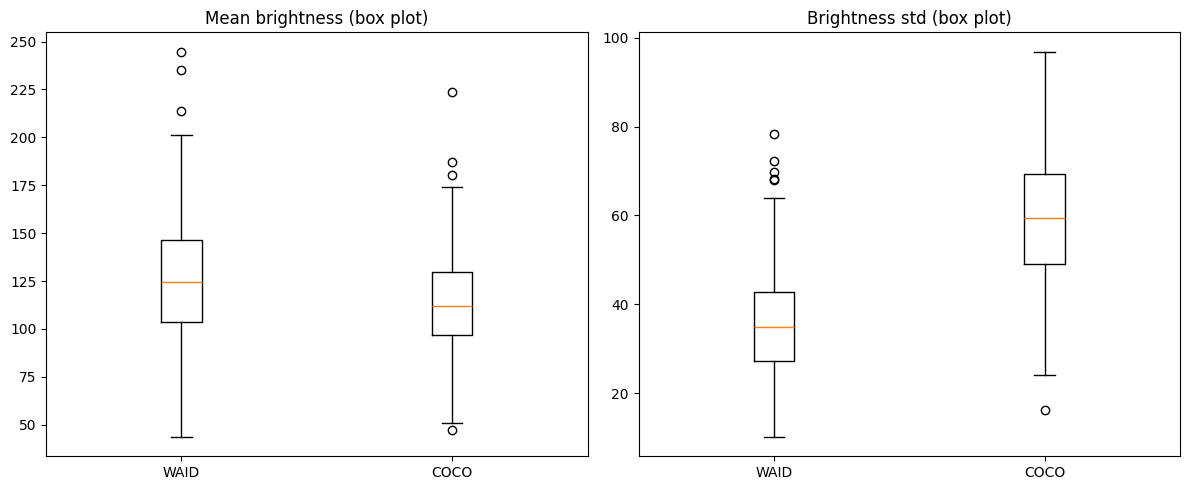

In [6]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < low) | (series > high)).sum()
    return n_out, low, high

for name, series in [("WAID brightness", stats_waid["mean"]),
                     ("COCO brightness", stats_coco["mean"]),
                     ("WAID std", stats_waid["std"]),
                     ("COCO std", stats_coco["std"])]:
    n_out, lo, hi = iqr_outliers(series)
    print(f"{name}: {n_out} outliers outside [{lo:.2f}, {hi:.2f}]  (IQR rule)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([stats_waid["mean"], stats_coco["mean"]], labels=["WAID", "COCO"])
axes[0].set_title("Mean brightness (box plot)")
axes[1].boxplot([stats_waid["std"], stats_coco["std"]], labels=["WAID", "COCO"])
axes[1].set_title("Brightness std (box plot)")
plt.tight_layout()
plt.show()


In [7]:
all_df = pd.concat([waid_df, coco_df], ignore_index=True)

corrupted = []
for path in all_df["image_path"]:
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        corrupted.append({"path": path, "error": str(e)})

print(f"total images checked: {len(all_df)}")
print(f"corrupted images:    {len(corrupted)}")
if corrupted:
    print()
    print("first 5 corrupted:")
    for c in corrupted[:5]:
        print(f"  {c['path']} -> {c['error']}")


total images checked: 17759
corrupted images:    0


bbox area and aspect by source:
       bbox_area_norm                                                    \
                count      mean       std       min       25%       50%   
source                                                                    
coco          17656.0  0.059376  0.119009  0.000014  0.002598  0.011532   
waid         233719.0  0.004313  0.008471  0.000002  0.001376  0.002077   

                           bbox_aspect                                \
             75%       max       count      mean       std       min   
source                                                                 
coco    0.052766  0.996403     17656.0  0.998188  0.861971  0.045547   
waid    0.004746  0.633389    233719.0  0.858012  0.716602  0.021053   

                                                 
             25%       50%       75%        max  
source                                           
coco    0.576307  0.836988  1.154061  29.481493  
waid    0.390805  0.640625  1.0

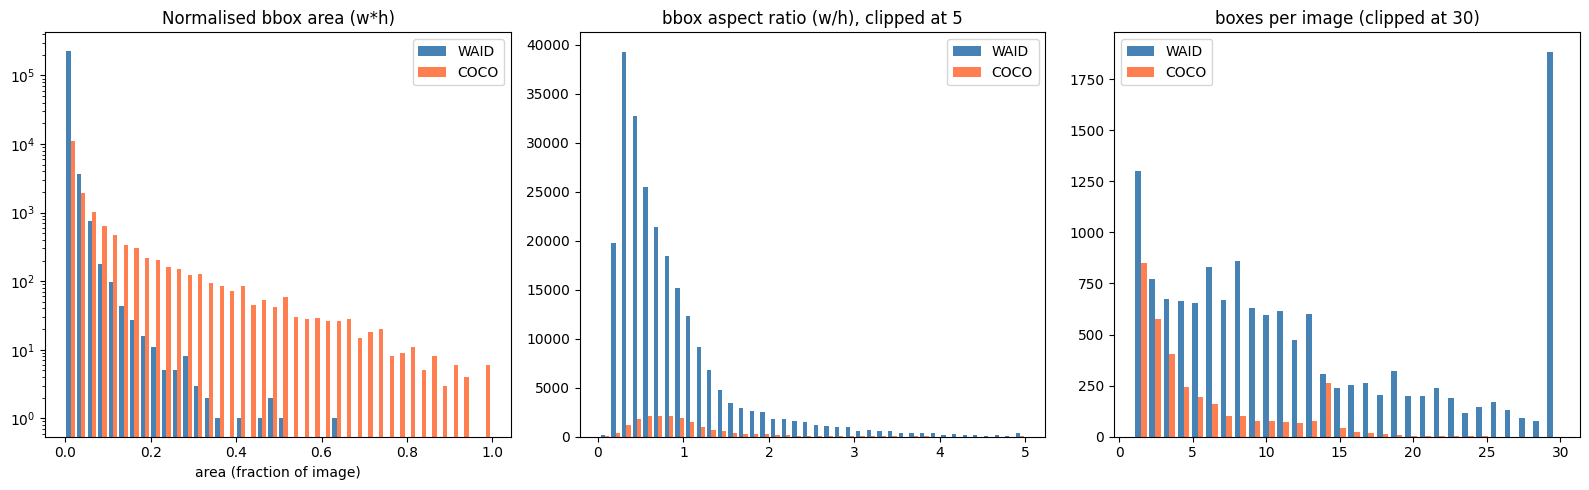

In [8]:
bbox_rows = []
for _, r in pd.concat([waid_df, coco_df]).iterrows():
    for cls, bb in zip(r["classes"], r["bboxes"]):
        cx, cy, w, h = bb
        bbox_rows.append({
            "source": r["source"],
            "class": cls,
            "bbox_area_norm": w * h,
            "bbox_aspect": w / h if h > 0 else np.nan,
        })

bbox_df = pd.DataFrame(bbox_rows)
print("bbox area and aspect by source:")
print(bbox_df.groupby("source")[["bbox_area_norm", "bbox_aspect"]].describe())
print()
print("boxes per image:")
print(pd.concat([waid_df, coco_df]).groupby("source")["n_boxes"].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(
    [bbox_df[bbox_df["source"] == "waid"]["bbox_area_norm"],
     bbox_df[bbox_df["source"] == "coco"]["bbox_area_norm"]],
    bins=40, label=["WAID", "COCO"], color=["steelblue", "coral"],
)
axes[0].set_title("Normalised bbox area (w*h)")
axes[0].set_xlabel("area (fraction of image)")
axes[0].legend()
axes[0].set_yscale("log")

axes[1].hist(
    [bbox_df[bbox_df["source"] == "waid"]["bbox_aspect"].clip(0, 5),
     bbox_df[bbox_df["source"] == "coco"]["bbox_aspect"].clip(0, 5)],
    bins=40, label=["WAID", "COCO"], color=["steelblue", "coral"],
)
axes[1].set_title("bbox aspect ratio (w/h), clipped at 5")
axes[1].legend()

axes[2].hist(
    [waid_df["n_boxes"].clip(0, 30), coco_df["n_boxes"].clip(0, 30)],
    bins=30, label=["WAID", "COCO"], color=["steelblue", "coral"],
)
axes[2].set_title("boxes per image (clipped at 30)")
axes[2].legend()
plt.tight_layout()
plt.show()


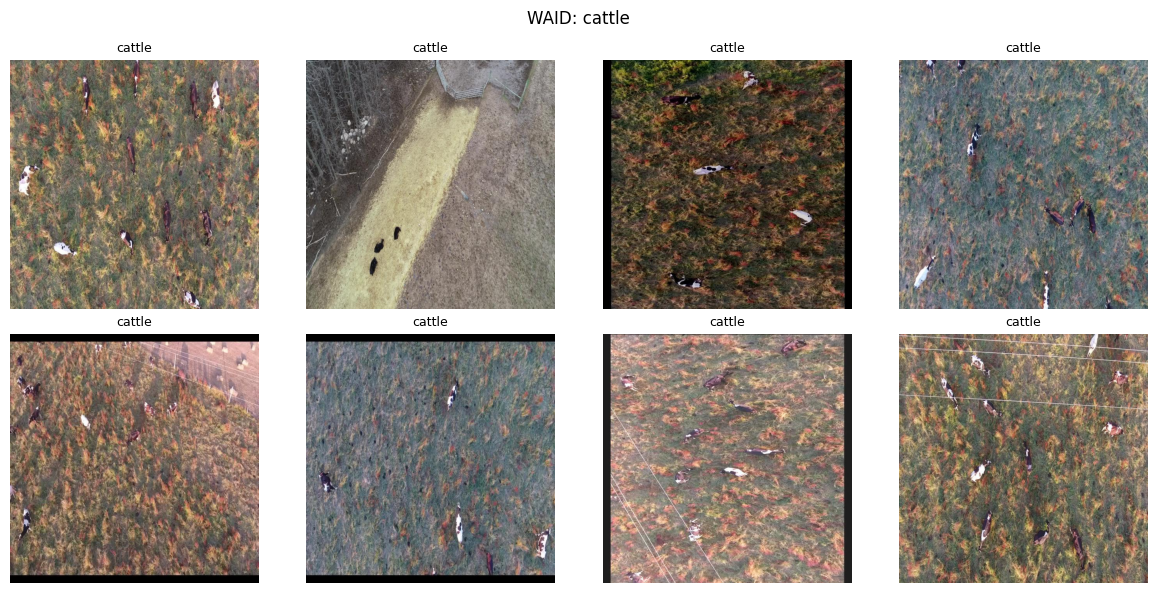

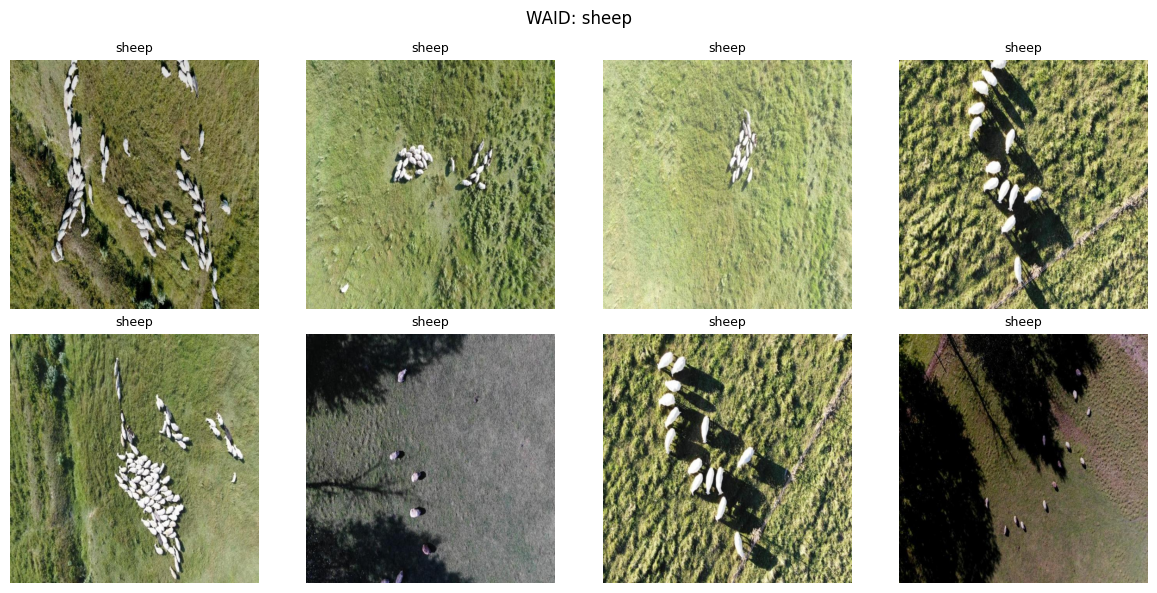

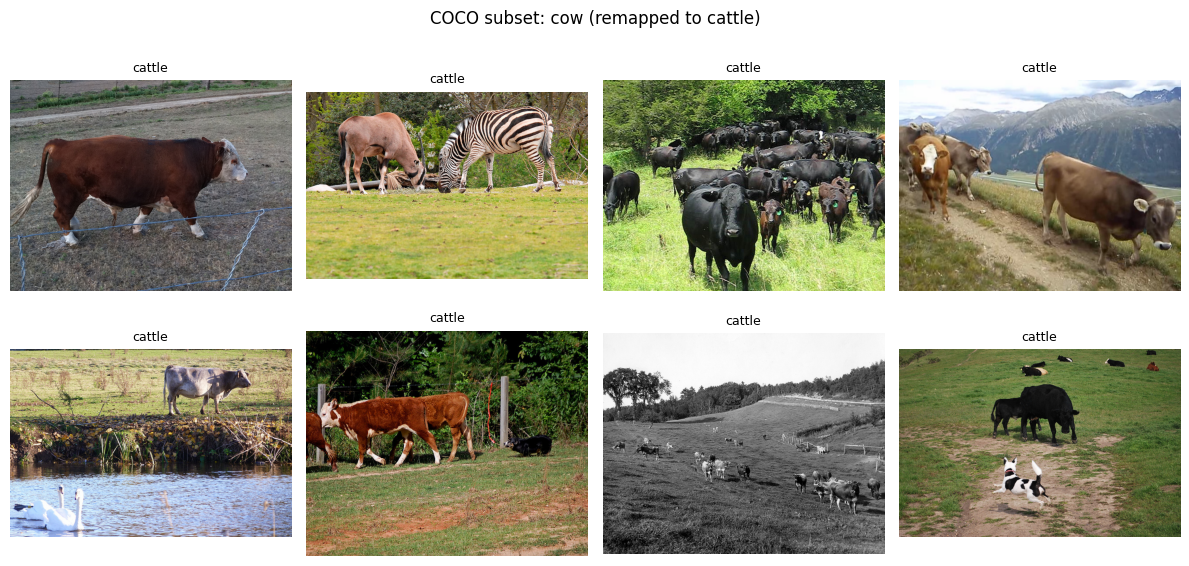

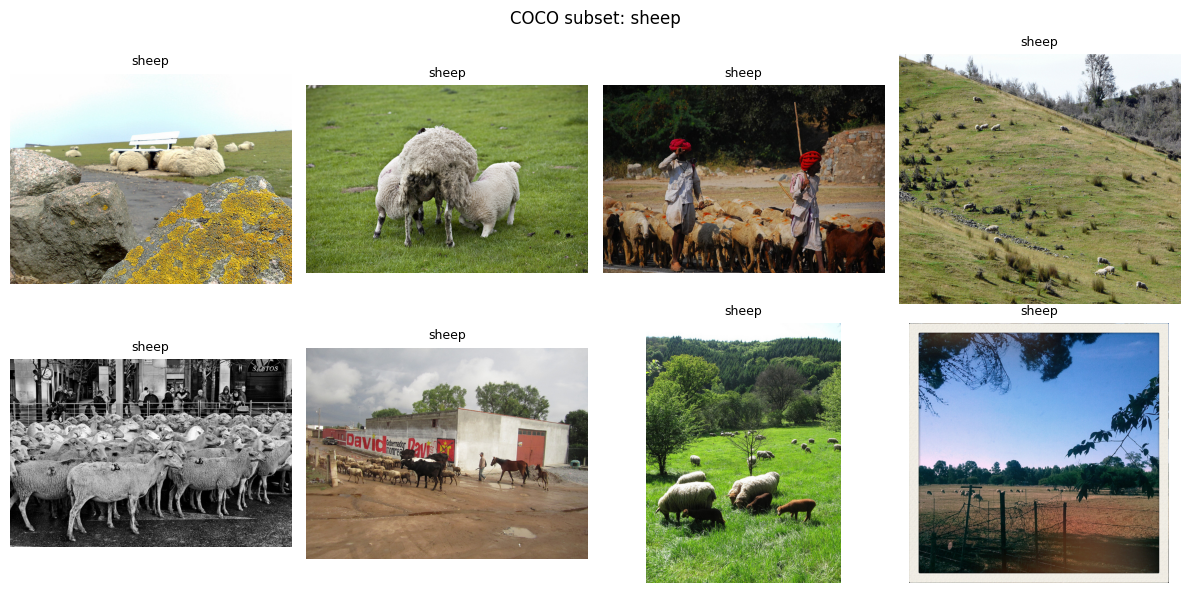

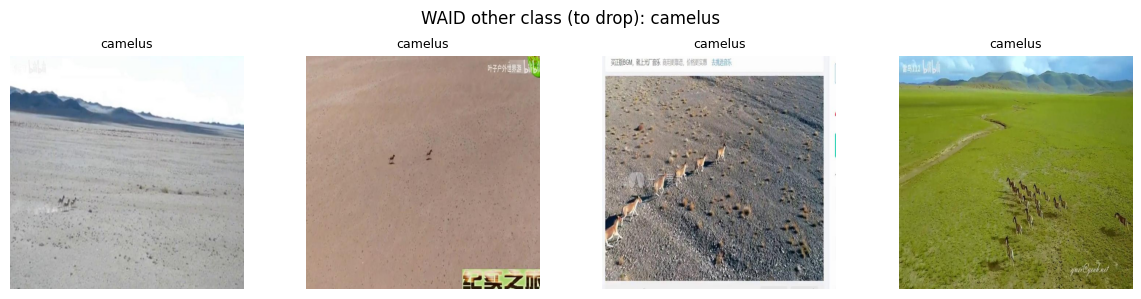

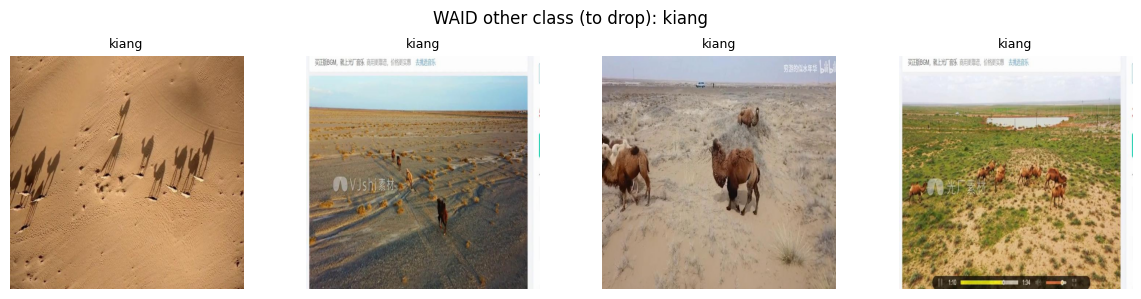

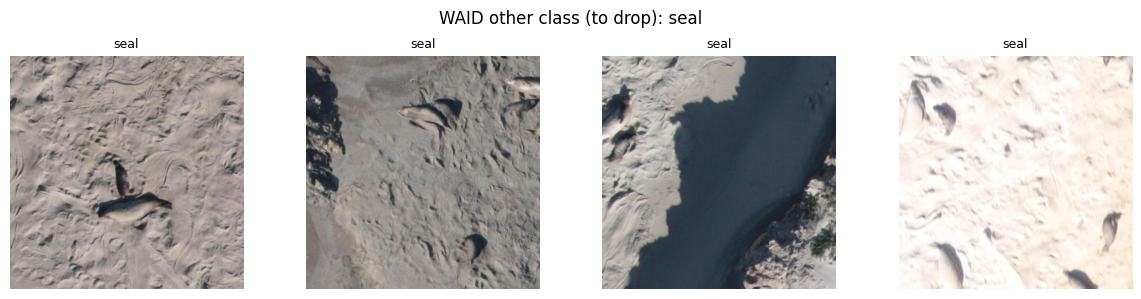

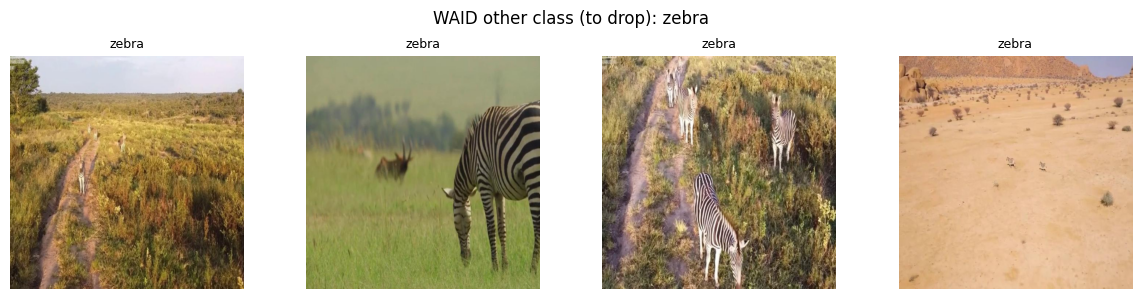

In [9]:
def show_samples(df, cls, n=8, cols=4, title=""):
    rows_with_cls = df[df["classes"].apply(lambda cs: cls in cs)]
    if len(rows_with_cls) == 0:
        print(f"no samples with class={cls}")
        return
    sample = rows_with_cls.sample(min(n, len(rows_with_cls)), random_state=SEED)
    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3, rows_n * 3))
    axes = np.atleast_2d(axes).flatten()
    for i, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(r["image_path"])
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9)
        axes[i].axis("off")
    for i in range(len(sample), len(axes)):
        axes[i].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(waid_df, "cattle", n=8, title="WAID: cattle")
show_samples(waid_df, "sheep", n=8, title="WAID: sheep")
show_samples(coco_df, "cattle", n=8, title="COCO subset: cow (remapped to cattle)")
show_samples(coco_df, "sheep", n=8, title="COCO subset: sheep")
for cls in ("camelus", "kiang", "seal", "zebra"):
    show_samples(waid_df, cls, n=4, cols=4, title=f"WAID other class (to drop): {cls}")


In [10]:
print("summary")
print()
print("total images:")
print(f"  WAID: {len(waid_df)}")
print(f"  COCO: {len(coco_df)}")

print("total boxes:")
print(f"  WAID: {waid_df['n_boxes'].sum()}")
print(f"  COCO: {coco_df['n_boxes'].sum()}")

print("WAID class distribution (boxes):")
print(waid_class_counts.to_string())

print("COCO class distribution (boxes):")
print(coco_class_counts.to_string())

print("classes to keep: cattle, sheep")
print("classes to drop from WAID: camelus, kiang, seal, zebra")

print(f"corrupted images: {len(corrupted)}")

print("normality (Shapiro-Wilk):")
for name, series in [("WAID", stats_waid["mean"]), ("COCO", stats_coco["mean"])]:
    w, p = stats.shapiro(series)
    print(f"  {name}: p={p:.4e}")


summary

total images:
  WAID: 14366
  COCO: 3393
total boxes:
  WAID: 233719
  COCO: 17656
WAID class distribution (boxes):
sheep      130810
cattle      63090
seal        23362
camelus      6623
zebra        5225
kiang        4609
COCO class distribution (boxes):
sheep     9509
cattle    8147
classes to keep: cattle, sheep
classes to drop from WAID: camelus, kiang, seal, zebra
corrupted images: 0
normality (Shapiro-Wilk):
  WAID: p=6.8525e-02
  COCO: p=6.7546e-02
